<a href="https://colab.research.google.com/github/danybereche-ctrl/ciencia-de-datos-/blob/main/Logiexpress_envios_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 Extrayendo las Tablas des Github
✅Primero ejecutamos esta celda. Descargamos la base de datos de logiexpress_envios directamente desde el repositorio de GitHub y abrimos: la conexión con SQLite.

In [ ]:
import requests
import sqlite3
import pandas as pd

BASE_URL = "https://raw.githubusercontent.com/Rociosayan/PMD1_Fundamentos_Gestion_Datos/main"
CASO = "09_logiexpress_envios"
DB_NAME = "logiexpress_envios.db"

url = f"{BASE_URL}/casos/{CASO}/{DB_NAME}"
respuesta = requests.get(url)
respuesta.raise_for_status()

with open(DB_NAME, "wb") as archivo:
    archivo.write(respuesta.content)

conn = sqlite3.connect(DB_NAME)

tablas = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)
tablas

## 1.1  📘Extrae toda la información histórica y completa de la tabla de envíos desde la base de datos y la carga en Python para empezar a trabajarla.

In [ ]:
df_envio_original=pd.read_sql_query("SELECT * FROM envios_original", conn)


## 1.2 visualizar toda la columna del dataset
1. 'display.max_columns':Significa "Cantidad máxima de columnas que se van a mostrar cuando imprima una tabla" y None para que me muestre sin limite las columnas del dataset.

In [ ]:
# el display.max_columns se utiliza mayormrnte cuando no puedes ver todas las columnas de una tabla
pd.set_option('display.max_columns', None)


# 2 Realizando copia del dataset, para no afectar el original

Si trabajas directamente sobre df_envio_original y cometes un error, borras algo o cambias datos, dañas tu fuente original. Al hacer esta copia, tú haces todos los cambios, limpiezas o pruebas en df_original_copy, y el original se queda intacto por si necesitas volver a consultarlo

In [ ]:
df_original_copy=df_envio_original.copy()

## Convertiendo **dataframe(df_original_copy)** a una tabla llamada **df_original_copy**

In [ ]:
""" #import sqlite3

#conn = sqlite3.connect(DB_NAME)

#df_original_copy.to_sql(
   # "df_original_copy",
   # conn,
    #if_exists="replace",
    #index=False
)

conn.commit() """

In [ ]:
#df_copia=pd.read_sql_query("SELECT * FROM df_original_copy", conn)


In [ ]:
""" tablas = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)
tablas"""

#  Análisis Exploratorio de Datos(EDA)



### Sample()
1.  ¿Cuándo usarlo?
Cuando quieres verificar si hay datos faltantes, valores extraños, errores de escritura o formatos incorrectos, y estos errores podrían estar en cualquier parte de la tabla (no solo al principio o final).

In [ ]:
df_original_copy.sample(frac=0.05)

## 2.1 EL dataset original está desnormalizada
1. En esta tabla se encuentra mezclado los datos:


*   La Entidad Cliente
*   La Entidad Envio
*   La Entidad Sede
*   La Entidad Tipo de Envio





In [ ]:
# con head mostramos las 2 primeras final de la tabla
df_original_copy.head(5)

In [ ]:
# mostramos el número de filas y columnas
df_original_copy.shape

In [ ]:
df_original_copy.columns

In [ ]:
# mostramos el tipo de datos que contiene cada columna
df_original_copy.dtypes

### info() del dataset


1.   <class 'pandas.core.frame.DataFrame'>, simplemente te confirma que esto es un DataFrame, que es la estructura de datos de Pandas
2. RangeIndex: 500 entries, 0 to 499, Tienes en total 500 filas o registros 0 to 499 es la numeración automática que le pone Python a cada fila (empieza a contar desde el cero).
3. Data columns (total 21 columns),la tabla tiene 21 columnas o variables en total

Antes de ralizar la normalizacion del dataframe, observamos que las columnas no se encuentran en un formato adecuado segun los tipos de datos


In [ ]:
# aqui mostramos la información que tipo de datos contienen cada columna del data set
df_original_copy.info()

### Evaluando si hay datos faltantes
para identificar si hay valores faltantes podemos utilizar como:


1.   isna()\te muestra dos opciones si es VERDAD existe datos faltantes y si es FALSO, no existe datos faltantes.
2.   isnull() y notnull()

como podemos observar la columna sedes_distrito contiene mayor datos con missing values (valores faltantes o perdidos)

In [ ]:
cantidad_nulos=df_original_copy.isnull().sum()
total_filas = len(df_original_copy)
porcentaje_nulos = (cantidad_nulos / total_filas) * 100
nulos_porcentaje_ordenado = porcentaje_nulos.sort_values(ascending=False)
tabla_nulos = pd.DataFrame({
    'Columna': nulos_porcentaje_ordenado.index,
    'Porcentaje_nulos': nulos_porcentaje_ordenado.values.round(2).astype(str) + ' %'
})

# Mostrar resultado
print("mostrando los datos nulos en porcentaje",tabla_nulos)

# Procentaje de valores duplicados
mostramos los registros que contengan valores repetidos o duplicados por cada columna del data set en porcentaje y es mas util para el analisis

In [ ]:
#  Porcentaje de valores duplicados por columna
print("\n=== Porcentaje de valores duplicados por columna ===")
porcentaje_duplicados = df_original_copy.apply(lambda col: round(col.duplicated().sum() / len(col) * 100, 2)).sort_values(ascending=False)
print(porcentaje_duplicados,"%")

In [ ]:
df_original_copy.sample(10)

In [ ]:
df_original_copy

In [ ]:
df_original_copy.tarifa_base=="26.64 aprox"

In [ ]:
pd.read_sql_query("""
SELECT COUNT(*) AS cantidad
FROM envios_original
WHERE clientes_nombre IS NULL
""", conn)

In [ ]:
df_original_copy['clientes_fecha_registro'].isnull().sum()

#3. Diagrama de la base de datos LOGIEXPRESS_ENVIOS

#### Explicasion

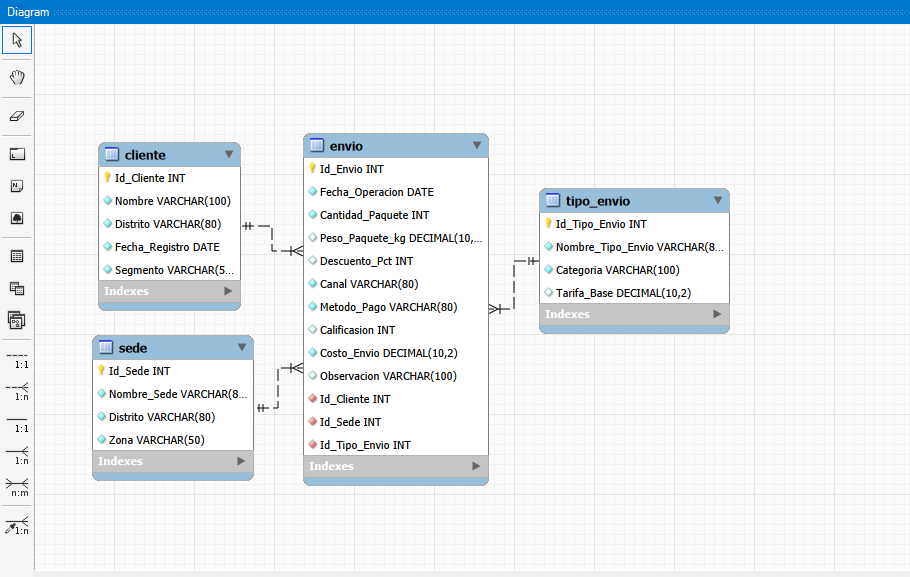

## 4. Crear tabla desde *df_original_copy*

### 4.1 Creando la Tabla Cliente

In [ ]:
cursor = conn.cursor()

# Make the pandas DataFrame available as a temporary SQL table
df_original_copy.to_sql('df_original_copy', conn, if_exists='replace', index=False)

cursor.execute("DROP TABLE IF EXISTS Cliente")

cursor.execute("""
CREATE TABLE Cliente(
    Id_Cliente INTEGER PRIMARY KEY AUTOINCREMENT,
    Nombre TEXT ,
    Distrito TEXT ,
    Fecha_Registro DATE ,
    Segmento TEXT
)
""")

cursor.execute("""
INSERT INTO Cliente(
    Nombre,
    Distrito,
    Fecha_Registro,
    Segmento
)
SELECT DISTINCT
    clientes_nombre,
    clientes_distrito,
    clientes_fecha_registro,
    clientes_segmento
FROM df_original_copy
""")

conn.commit()

df_cliente = pd.read_sql_query( "SELECT * FROM Cliente",conn)
#df_cliente.head()
#cerramos la coneccion
#conn.close()


In [ ]:
df_cliente.head()


### 4.2 Creando la Tabla Sede

In [ ]:
cursor = conn.cursor()

cursor.execute("DROP TABLE IF EXISTS Sede")

cursor.execute("""
CREATE TABLE Sede(
    Id_Sede INTEGER PRIMARY KEY AUTOINCREMENT,
    Nombre_Sede TEXT NOT NULL,
    Distrito TEXT,
    Zona TEXT NOT NULL
)
""")

cursor.execute("""
INSERT INTO Sede(
    Nombre_Sede,
    Distrito,
    Zona
)
SELECT DISTINCT
    sedes_nombre,
    sedes_distrito,
    sedes_zona
FROM df_original_copy
""")

conn.commit()

df_sede = pd.read_sql_query( "SELECT * FROM Sede",conn)
#cerramos la coneccion
#conn.close()

In [ ]:
df_sede.sample(4)

### 4.3 Creando la Tabla Tipo de Envio

In [ ]:
cursor = conn.cursor()

cursor.execute("DROP TABLE IF EXISTS Tipo_Envio")

cursor.execute("""
CREATE TABLE Tipo_Envio(
    Id_Tipo_Envio INTEGER PRIMARY KEY AUTOINCREMENT,
    Nombre_Tipo_Envio TEXT NOT NULL,
    Categoria TEXT,
    Tarifa_Base decimal(10,2) NOT NULL
)
""")

cursor.execute("""
INSERT INTO Tipo_Envio(
     Nombre_Tipo_Envio,
     Categoria,
     Tarifa_Base
)
SELECT DISTINCT
    tipos_envio_nombre,
    tipos_envio_categoria,
    tipos_envio_tarifa_base
FROM df_original_copy
""")

conn.commit()

df_tipo_envio = pd.read_sql_query( "SELECT * FROM Tipo_Envio",conn)
#cerramos la coneccion
#conn.close()

In [ ]:
df_tipo_envio

### 4.3 Creando la Tabla Envio

In [ ]:
df_copia = df_original_copy.copy()

In [ ]:
df_copia.sample(10)

In [ ]:
cursor = conn.cursor()

cursor.execute("DROP TABLE IF EXISTS Envio_Nueva")

cursor.execute("""
CREATE TABLE Envio_Nueva(
    Id_Envio INTEGER PRIMARY KEY AUTOINCREMENT,
    Fecha_Operacion DATE,
    Cantidad_Paquete INTEGER,
    Peso_Paquete_kg DECIMAL(10,2),
    Descuento_Pct INTEGER,
    Canal VARCHAR(80) ,
    Metodo_Pago VARCHAR(80),
    Calificasion INTEGER,
    Costo_Envio DECIMAL(10,2),
    Observacion VARCHAR(100),

    Id_Cliente INTEGER NOT NULL,
    Id_Sede INTEGER NOT NULL,
    Id_Tipo_Envio INTEGER NOT NULL,

    FOREIGN KEY (Id_Cliente) REFERENCES Cliente(Id_Cliente),
    FOREIGN KEY (Id_Sede) REFERENCES Sede(Id_Sede),
    FOREIGN KEY (Id_Tipo_Envio) REFERENCES Tipo_Envio(Id_Tipo_Envio)
)
""")

cursor.execute("""
INSERT INTO Envio_Nueva(
    Fecha_Operacion,
    Cantidad_Paquete,
    Peso_Paquete_kg,
    Descuento_Pct,
    Canal,
    Metodo_Pago,
    Calificasion,
    Costo_Envio,
    Observacion,
    Id_Cliente,
    Id_Sede,
    Id_Tipo_Envio
)
SELECT
    poc.fecha_operacion,
    poc.cantidad_paquete,
    poc.peso_paquete_kg,
    poc.descuento_pct,
    poc.canal,
    poc.metodo_pago,
    poc.calificasion,
    poc.costo_envio,
    poc.observacion,
    c.Id_Cliente,
    s.Id_Sede,
    te.Id_Tipo_Envio
FROM df_original_copy poc
INNER JOIN Cliente c ON poc.clientes_nombre = c.Nombre
INNER JOIN Sede s ON poc.sedes_nombre = s.Nombre_Sede
INNER JOIN Tipo_Envio te ON poc.tipos_envio_nombre = te.Nombre_Tipo_Envio

""")

conn.commit()

df_envio = pd.read_sql_query( "SELECT * FROM Envio_Nueva",conn)
#cerramos la coneccion
#conn.close()

In [ ]:
df_copia.columns.to_list()

In [ ]:
Con.close()